# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('data-imbalance-causal-forest'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import norm

# estimators
from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS

from scipy.integrate import quad 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 

# Base example

In [6]:
num_obs = 1000  # number of observations
num_covariates = 10  # number of covariates

# generate covariates
relu_te_func = lambda x: np.maximum(x[:, 0], 0)  # true treatment effect function

def sample1(te_func: callable, sample_size: int, seed: int = None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # generate covariates
    X_arr = np.random.normal(size=(sample_size, num_covariates))  # Gaussian covariates with shape = (sample_size, num_covariates)
    W_arr = np.random.binomial(1, 0.5, size=(sample_size, ))  # binary treatment, shape = (sample_size, 1)

    Y_arr = te_func(X_arr) * W_arr + X_arr[:, 1] + np.maximum(X_arr[:, 2], 0) + np.random.normal(size=(sample_size, ))  # outcome, shape = (sample_size, 1)

    return X_arr, W_arr, Y_arr


In [7]:
cf = CausalForest()

In [23]:
def run_simple_causal_forest(X: np.ndarray, W: np.ndarray, Y: np.ndarray) -> CausalForest:
    # define causal forest
    cf = CausalForest()

    # fit causal forest to data set
    cf.fit(X=X, T=W, y=Y)

    # get CATE estimates
    # tau_pred = cf.oob_predict(X).flatten()  # (N, )

    return cf

def run_bootstrapped_causal_forest(
        X: np.ndarray, W: np.ndarray, Y: np.ndarray, num_bootstraps: int = 50, bootstrap_sample_size: int = 500
) -> list: 
    cf_list = [None for _ in range(num_bootstraps)]
    for i in range(num_bootstraps):
        # sample with replacement
        idx = np.random.choice(range(X.shape[0]), size=bootstrap_sample_size, replace=True)

        # fit causal forest to data set
        cf = CausalForest()
        cf.fit(X=X[idx], T=W[idx], y=Y[idx])

        # get CATE estimates
        # tau_pred = cf.predict(X).flatten()

        cf_list[i] = cf

    return cf_list 

def booststrap_cf_predict(cf_list: list, X: np.ndarray) -> np.ndarray:
    tau_pred = np.zeros((X.shape[0], len(cf_list)))
    for i, cf in enumerate(cf_list):
        tau_pred[:, i] = cf.predict(X).flatten()  # (N, num_bootstraps)

    return tau_pred.mean(axis=1)

In [60]:
te_func = relu_te_func   # true treatment effect function

# generate training set
X_arr, W_arr, Y_arr = sample1(te_func, num_obs, seed=123)

# generate test set
X_test_arr, W_test_arr, Y_test_arr = sample1(te_func, num_obs, seed=1234)

# fit simple causal forest
simple_cf = run_simple_causal_forest(X_arr, W_arr, Y_arr)

# fit bootstrapped causal forest
bootstrapped_cf_list = run_bootstrapped_causal_forest(X_arr, W_arr, Y_arr, num_bootstraps=100, bootstrap_sample_size=100)

In [61]:
simple_cf_pred = simple_cf.predict(X_test_arr).flatten()
bootstrapped_cf_pred = booststrap_cf_predict(bootstrapped_cf_list, X_test_arr)

# calculate rmse 
simple_cf_rmse = np.sqrt(np.mean((simple_cf_pred - te_func(X_test_arr))**2))
bootstrapped_cf_rmse = np.sqrt(np.mean((bootstrapped_cf_pred - te_func(X_test_arr))**2))

print(f"Simple causal forest RMSE: {simple_cf_rmse:.3f}")
print(f"Bootstrapped causal forest RMSE: {bootstrapped_cf_rmse:.3f}")

Simple causal forest RMSE: 0.558
Bootstrapped causal forest RMSE: 0.561


In [49]:
# # out of sample performance
# test_performance_df = pd.DataFrame({
#     'tau_pred': cf.predict(X_test_arr).flatten(),
#     'tau_true': te_func(X_test_arr)
# })
# # get estimator variance 
# _, tau_var = cf.predict_and_var(X_test_arr)
# tau_var = tau_var.flatten()
# # get confidence intervals
# alpha = 0.05
# phi = norm.ppf(1 - alpha / 2)
# test_performance_df.insert(2, 'tau_ci_lb', test_performance_df['tau_pred'] - phi * np.sqrt(tau_var))
# test_performance_df.insert(3, 'tau_ci_ub', test_performance_df['tau_pred'] + phi * np.sqrt(tau_var))
# test_performance_df.insert(4, 'is_significant', (test_performance_df['tau_ci_lb'] > 0) | (test_performance_df['tau_ci_ub'] < 0))

# # calculate performance metrics
# test_rmse = np.mean((test_performance_df['tau_pred'] - test_performance_df['tau_true']) ** 2) ** 0.5

# print(f'\nTest RMSE: {test_rmse:.2f}')
# print('Test set 95% significant coverage: {:.2%}\n'.format(test_performance_df['is_significant'].mean()))

In [57]:
# decision making
num_obs = 500
budget = 100
num_repeats = 100
clairvoyant_list = [None for _ in range(num_repeats)]
simple_cf_list = [None for _ in range(num_repeats)]
bootstrapped_cf_results_list = [None for _ in range(num_repeats)]

for i in tqdm(range(num_repeats)):
    X_arr, _, _ = sample1(te_func, num_obs)

    # get treatment effect and its variance
    simple_cf_pred = simple_cf.predict(X_arr).flatten()
    bootstrapped_cf_pred = booststrap_cf_predict(bootstrapped_cf_list, X_arr)

    te_true = te_func(X_arr)

    clairvoyant_list[i] = np.sort(te_true)[-budget:].sum()
    simple_cf_list[i] = te_true[np.argsort(-simple_cf_pred)[-budget:]].sum()
    bootstrapped_cf_results_list[i] = te_true[np.argsort(-bootstrapped_cf_pred)[-budget:]].sum()


result_df = pd.DataFrame({
    'clairvoyant': clairvoyant_list,
    'simple_cf': simple_cf_list,
    'bootstrapped_cf': bootstrapped_cf_results_list
})

100%|██████████| 100/100 [08:31<00:00,  5.12s/it]


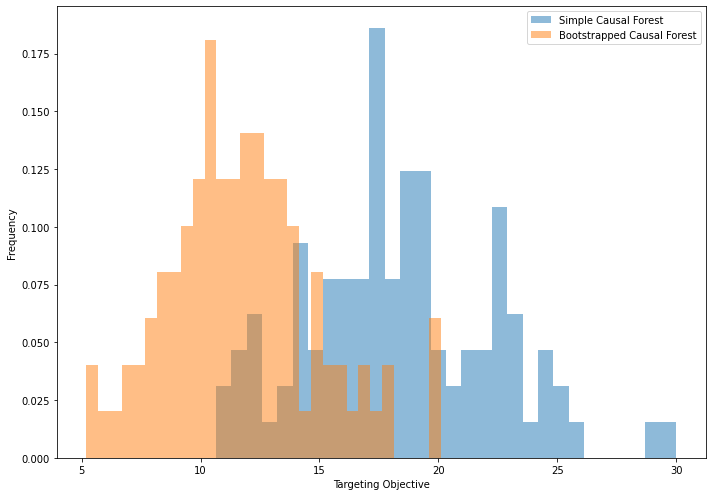

       clairvoyant   simple_cf  bootstrapped_cf
count   100.000000  100.000000       100.000000
mean    139.419937   18.349045        11.759167
std       7.776202    3.948283         3.108380
min     123.130524   10.651947         5.197210
25%     133.750931   15.714950         9.742195
50%     139.139384   17.908930        11.397118
75%     144.850101   21.097182        13.409753
max     162.356175   29.993898        20.117876


In [58]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(simple_cf_list, bins=30, alpha=0.5, density=True, label='Simple Causal Forest')
ax.hist(bootstrapped_cf_results_list, bins=30, alpha=0.5, density=True, label='Bootstrapped Causal Forest')

ax.set_xlabel('Targeting Objective')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(result_df.describe())

In [201]:
# decision making
num_obs = 500
budget = 100
num_repeats = 1000
clairvoyant_list = [None for _ in range(num_repeats)]
cf_eto_list = [None for _ in range(num_repeats)]
cf_ucb_list = [None for _ in range(num_repeats)]
cf_lcb_list = [None for _ in range(num_repeats)]

for i in tqdm(range(num_repeats)):
    X_arr, _, _ = sample1(te_func, num_obs)

    # get treatment effect and its variance
    tau_pred, tau_var = cf.predict_and_var(X_arr)
    tau_pred, tau_var = tau_pred.flatten(), tau_var.flatten()
    te_true = te_func(X_arr)

    clairvoyant_list[i] = np.sort(te_true)[-budget:].sum()
    cf_eto_list[i] = te_true[np.argsort(-tau_pred)[-budget:]].sum()
    cf_ucb_list[i] = te_true[np.argsort(-tau_pred - phi * np.sqrt(tau_var))[-budget:]].sum()
    cf_lcb_list[i] = te_true[np.argsort(-tau_pred + phi * np.sqrt(tau_var))[-budget:]].sum()

    # print('Clairvoyant targeting objective: {:.2f}'.format(optimal_targeting_obj))
    # print('Causal forest targeting objective: {:.2f}'.format(cf_targeting_obj))
    # print('Causal forest UCB targeting objective: {:.2f}'.format(cf_ucb_targeting_obj))
    # print('Causal forest LCB targeting objective: {:.2f}'.format(cf_lcb_targeting_obj))

result_df = pd.DataFrame({
    'clairvoyant': clairvoyant_list,
    'cf_eto': cf_eto_list,
    'cf_ucb': cf_ucb_list,
    'cf_lcb': cf_lcb_list
})

100%|██████████| 1000/1000 [00:28<00:00, 35.16it/s]


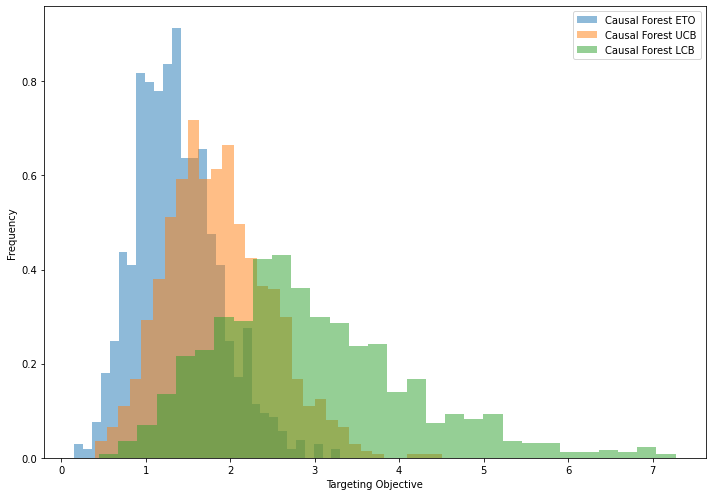

       clairvoyant       cf_eto       cf_ucb       cf_lcb
count  1000.000000  1000.000000  1000.000000  1000.000000
mean    139.379523     1.368142     1.860308     2.938873
std       6.685054     0.491099     0.617734     1.176311
min     117.058721     0.151563     0.401795     0.446441
25%     134.951475     1.007272     1.422300     2.122586
50%     139.328476     1.326126     1.801165     2.761687
75%     143.869133     1.672776     2.264391     3.615344
max     163.258637     3.303753     4.502586     7.272281


In [204]:
fig, ax = plt.subplots(figsize=(10, 7))

# ax.hist(clairvoyant_list, bins=30, alpha=0.5, label='Clairvoyant')
ax.hist(cf_eto_list, bins=30, alpha=0.5, density=True, label='Causal Forest ETO')
ax.hist(cf_ucb_list, bins=30, alpha=0.5, density=True, label='Causal Forest UCB')
ax.hist(cf_lcb_list, bins=30, alpha=0.5, density=True, label='Causal Forest LCB')

ax.set_xlabel('Targeting Objective')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(result_df.describe())

# Group targeting

## Case 1

There are $K$ customers, each with $N$ observations. The DGP is the simplest possible: no individual characteristics needed. binary. 

$$
\begin{aligned}
Y_{ki} & = \tau_k T_i + \mathcal{N}(0, \sigma_Y^2) \\ 
T_{i} & \sim B(0.5)
\end{aligned}
$$

In [30]:
""" 
Data Generation Process
"""
random.seed = 1
np.random.seed(1)

num_cust = 5  # number of customers (or customer clusters)
num_obs = 10  # number of observations for each customers

# generate true treatment effect
te_arr = np.random.uniform(-1, 1, size=(num_cust, ))  # (num_cust, ): treatment effect for each customers (HTE)

# binary
treatment_arr = np.random.binomial(1, 0.5, size=(num_cust, num_obs))  # (num_cust, num_obs)

# generate outcome based on treatment and treatment effect
outcome_arr = treatment_arr * np.repeat(te_arr.reshape(-1, 1), num_obs, axis=1) + np.random.normal(0, 0.01, size=(num_cust, num_obs))  # (num_cust, num_obs)

In [8]:
"""
Estimation
"""

# estimate treatment effect
te_estimate_arr = np.zeros(shape=(num_cust, ))
for k in range(num_cust):
    ols = OLS(endog=outcome_arr[k].flatten(), exog=treatment_arr[k].flatten()).fit()
    te_estimate_arr[k] = ols.params[0]

# estimation result analysis
result = pd.DataFrame({
    'True TE': te_arr, 'Estimated TE': te_estimate_arr
})

result

,True TE,Estimated TE
0,-0.165956,-0.164286
1,0.440649,0.445622
2,-0.999771,-0.998726
3,-0.395335,-0.397468
4,-0.706488,-0.705123


In [9]:
""" 
Targeting 
"""
capacity = 2  # out of the K customers, how many are we targeting 

estimated_targeting_arr = np.argsort(-te_estimate_arr)[:capacity]  # selected customers based on estimated treatment effect
true_targeting_arr = np.argsort(-te_arr)[:capacity]  # selected customers based on true treatment effect

true_targeting_value = te_arr[true_targeting_arr].sum()
estimated_targeting_value = te_estimate_arr[estimated_targeting_arr].sum()
true_estimated_targeting_value = te_arr[estimated_targeting_arr].sum()

print(f'Estimated targeting value = {estimated_targeting_value:.4f}')
print(f'True value of targeting based on estimation = {true_estimated_targeting_value:.4f}')
print(f'Best targeting value achievable = {true_targeting_value:.4f}')

Estimated targeting value = 0.2813
True value of targeting based on estimation = 0.2747
Best targeting value achievable = 0.2747


## Case 2

There are $K$ groups of customers, each with $N_k$ observations. In this case the researchers observe individual characteristics $\vec{X}_{ki}\in \mathcal{X}\subset\mathbb{R}^D$. The heterogeneous treatment effect is a $\mathcal{X}$-measurable function $\tau: \mathcal{X} \mapsto \mathbb{R}$. The DGP is the following: 

$$
\begin{aligned}
Y_{ki} & = \tau(\vec{X}_{ki}) T_{ki} + \mathcal{N}(0, \sigma_Y^2) \\
T_{ki} & \sim B(p) \\ 
\vec{X}_{ki} & \sim \mathcal{N}(\vec{\mu}_k, \text{diag}(\vec{\sigma}_k^2)),\;\quad \forall\; k \\ 
\vec{\mu}_k & \sim U[-1, 1]^D,\;\quad \forall\; k \\ 
\vec{\sigma}_k & \sim U[0, 1]^D,\;\quad \forall\; k
\end{aligned}
$$

In [6]:
""" 
Data Generation Process
"""
def generate_customer_groups(num_cust: int, feat_dim: int) -> tuple:
    sigma_arr = np.random.uniform(0, 0.5, size=(num_cust, feat_dim))  # (num_cust, feat_dim): standard deviation of each feature for each customer
    mu_arr = np.random.uniform(-0.1, 0.1, size=(num_cust, feat_dim))  # (num_cust, feat_dim): mean of each feature for each customer

    return mu_arr, sigma_arr

def generate_individual(mu: np.ndarray, sigma: np.ndarray, num_obs: int, feat_dim: int) -> np.ndarray:
    # individual characteristics
    num_cust = mu.shape[0]
    X_arr = np.zeros(shape=(num_cust, num_obs, feat_dim))
    for cust_id in range(num_cust):
        X_arr[cust_id] = np.random.multivariate_normal(mu[cust_id], np.diag(sigma[cust_id]), size=num_obs)

    return X_arr

def generate_training_set(num_cust: int, num_obs: int, feat_dim: int, te_func: callable, meta_data: dict = None) -> tuple:
    """ 
    Sample data from the data generation process

    Return 
    ------
    (meta_data, data): meta_data contains the prior parameteres mu and sigma, data contains X, T, Y
    """

    # generate customer groups (prior parameters)
    if meta_data is None:
        mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)  # (num_cust, feat_dim), (num_cust, feat_dim)
    else:
        mu_arr, sigma_arr = meta_data['mu'], meta_data['sigma']

    # generate individual characteristics
    X_arr = generate_individual(mu_arr, sigma_arr, num_obs, feat_dim)  # (num_cust, num_obs, feat_dim)

    # generate treatment effect
    te_arr = te_func(X_arr)  # (num_cust, num_obs)

    # generate treatment variables
    treatment_arr = np.random.binomial(1, 0.5, size=(num_cust, num_obs))  # (num_cust, num_obs)

    # generate outcome variables
    outcome_arr = te_arr * treatment_arr + np.random.normal(0, 0.1, size=(num_cust, num_obs))  # (num_cust, num_obs)

    return {'mu': mu_arr, 'sigma': sigma_arr}, {'X': X_arr, 'T': treatment_arr, 'Y': outcome_arr}

In [7]:
"""  
Preprocessing
"""
def prepare_training_data(data: dict) -> dict:
    train_treatment_arr = data['T'].flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
    train_outcome_arr = data['Y'].flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
    train_X_arr = data['X'].reshape(-1, data['X'].shape[-1])  # (num_cust, num_obs, feat_dim) -> (num_cust * num_obs, feat_dim)

    return {
        'X': train_X_arr, 'T': train_treatment_arr, 'Y': train_outcome_arr
    }

In [8]:
"""  
Training and estimation
"""
def train_vanilla_causal_forest(X: np.ndarray, T: np.ndarray, Y: np.ndarray) -> CausalForest:
    cf = CausalForest(n_estimators=100)
    cf.fit(X=X, T=T, y=Y)

    return cf

def train_bootstrapped_causal_forest(
        X: np.ndarray, T: np.ndarray, Y: np.ndarray, num_bootstraps: int = 50, bootstrap_sample_size: int = 500
) -> list: 
    cf_list = [None for _ in range(num_bootstraps)]
    for i in range(num_bootstraps):
        # sample with replacement
        idx = np.random.choice(range(X.shape[0]), size=bootstrap_sample_size, replace=True)

        # fit causal forest to data set
        cf = CausalForest()
        cf.fit(X=X[idx], T=T[idx], y=Y[idx])

        cf_list[i] = cf

    return cf_list

def estimate_via_vanila_causal_forest(cf: CausalForest, X: np.ndarray) -> tuple:
    """ 

    Input 
    -----
    cf: trained CausalForest object
    X: (N, feat_dim)
    
    Return 
    ------
    (te_est, te_var): tuple of np.ndarray, treatment effect prediction (num_cust * num_obs, 1)
      and its variance (num_cust * num_obs, 1)
    """
    te_est, te_var = cf.predict_and_var(X)
    
    return te_est.flatten(), te_var.flatten()

def estimate_via_bootstrapped_causal_forest(cf_list: list, X: np.ndarray) -> pd.DataFrame:
    """ 
    
    Input 
    -----
    cf_list: list of trained CausalForest objects
    X: shape = (N, feat_dim)

    Return
    ------
    pd.DataFrame: (N, num_bootstraps), treatment effect prediction for each observation (row) and each bootstrap (column)
    """

    return pd.DataFrame({
        f'Booststrap {i}': cf.predict(X).flatten()
        for i, cf in enumerate(cf_list)
    })  # (N, num_bootstraps)

In [9]:
"""  
Estimator performance evaluation
"""
pass  # TODO 

# # in sample prediction
# te_est_arr = cf.oob_predict(Xtrain=train_X_arr).flatten()  # (num_cust * num_obs, )

# result = pd.DataFrame({
#     'True TE': te_arr.flatten(), 
#     'Estimated TE': te_est_arr
# })

# result

# # out of sample prediction
# te_est_arr, te_var_arr = cf.predict_and_var(test_X_arr.reshape(-1, feat_dim))
# te_est_arr, te_var_arr = te_est_arr.flatten(), te_var_arr.flatten()
# true_te_arr = te_func(test_X_arr).flatten()

# result = pd.DataFrame({
#     'True TE': true_te_arr, 
#     'Estimated TE': te_est_arr
# })

# result

In [10]:
"""  
Targeting problem
"""
def empirical_targeting(te_est_arr: np.ndarray, budget: int) -> tuple:
    """ 
    Empirical targeting strategy, select top K customers based on estimated treatment effect

    Return
    ------
    (objective value, decision arr): (float, np.ndarray), targeting value and indices of the selected customers (K, )

    """
    return np.sort(te_est_arr)[-budget:].sum(), np.sort(np.argsort(-te_est_arr)[:budget])

def bootstrap_targeting(bootstrap_te_est_df: pd.DataFrame, budget: int) -> tuple:
    """ 
    Bootstrap targeting strategy, select top K customers based on the bootstrap estimated treatment effect

    Return
    ------
    (objective value, decision arr): (float, np.ndarray), targeting value and indices of the selected customers (K, )
    """
    # get top K customers for each bootstrap
    topk_df = pd.DataFrame({
        col: bootstrap_te_est_df[col].nlargest(budget).index.values    
        for col in bootstrap_te_est_df.columns
    })

    # count the appearance of each customer in the top K
    count_df = topk_df.stack().value_counts()

    # sort by the count
    count_df.sort_values(ascending=False, inplace=True)

    # estimates of the targeting value
    topk_val_df = pd.DataFrame({
        col: bootstrap_te_est_df[col].nlargest(budget).values    
        for col in bootstrap_te_est_df.columns
    })
    val = topk_val_df.sum(axis=0).mean()

    return val, np.sort(count_df.index[:budget].values)


def evaluate_targeting_policy(true_te_arr: np.ndarray, targeting_arr: np.ndarray) -> float:
    """ 
    Evaluate targeting policies based on the true treatment effect

    Input 
    -----
    true_te_arr: (N, ) true treatment effect for each observation
    targeting_arr: (K, ) indices of the selected customers for targeting

    Return 
    ------
    float: targeting value
    """
    return true_te_arr[targeting_arr].sum()

In [100]:
# training parameters
num_cust = 10  # number of customers (or customer clusters)
num_obs = 500 # number of observations for each group of customers
feat_dim = 10  # number of features for each indivdiual
te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function
# te_func = lambda x_arr: np.maximum(x_arr[:, :, 0], 0)  # true treatment effect function

# testing parameters
num_test_obs = 1  # number of test observations for each group of customers

# decision making parameters
budget = 3  # number of customers to target

# generate raw data
meta_dict, data_dict = generate_training_set(num_cust, num_obs, feat_dim, te_func)
test_x_arr = generate_individual(**meta_dict, num_obs=num_test_obs, feat_dim=feat_dim)  # (num_cust, num_test_obs, feat_dim)

# data preparation
train_dict = prepare_training_data(data_dict)

# train estimators
vanilla_cf = train_vanilla_causal_forest(**train_dict)
boot_cf_list = train_bootstrapped_causal_forest(**train_dict, num_bootstraps=100, bootstrap_sample_size=5 * num_cust * num_obs)

# estimate treatment effect for test data
te_est_arr, te_var_arr = estimate_via_vanila_causal_forest(vanilla_cf, test_x_arr.reshape(-1, feat_dim))
boot_te_est_df = estimate_via_bootstrapped_causal_forest(boot_cf_list, test_x_arr.reshape(-1, feat_dim))

# making targeting decisions
best_targeting_arr = np.sort(np.argsort(-te_func(test_x_arr).flatten())[:budget])
emp_targeting_val, emp_targeting_arr = empirical_targeting(te_est_arr, budget)
boot_targeting_val, boot_targeting_arr = bootstrap_targeting(boot_te_est_df, budget)

# evaluate targeting policies
true_te_arr = te_func(test_x_arr).flatten()
best_targeting_val = evaluate_targeting_policy(true_te_arr, best_targeting_arr)
true_emp_targeting_val = evaluate_targeting_policy(true_te_arr, emp_targeting_arr)
true_boot_targeting_val = evaluate_targeting_policy(true_te_arr, boot_targeting_arr)

# compare results
targeting_comp_df = pd.DataFrame({
    'Claivoyant': best_targeting_arr, 
    'Empirical': emp_targeting_arr,
    'Bootstrap': boot_targeting_arr
})
targeting_val_comp_df = pd.DataFrame({
    'Clairvoyant': {'in-sample': np.nan, 'out-of-sample': best_targeting_val}, 
    'Empirical': {'in-sample': emp_targeting_val, 'out-of-sample': true_emp_targeting_val},
    'Bootstrap': {'in-sample': boot_targeting_val, 'out-of-sample': true_boot_targeting_val}
})

print(targeting_comp_df)
print(targeting_val_comp_df)

   Claivoyant  Empirical  Bootstrap
0           0          0          0
1           4          4          4
2           9          9          9
               Clairvoyant  Empirical  Bootstrap
in-sample              NaN   2.637908   2.689819
out-of-sample     2.605206   2.605206   2.605206


In [101]:
# bootstrap columns
num_boots = 500 

new_boot_targeting_arr = np.zeros((num_boots, budget))
new_boot_val_arr = np.zeros(num_boots)

for i in range(num_boots):
    temp = boot_te_est_df[np.random.choice(boot_te_est_df.columns, size=boot_te_est_df.shape[0], replace=True)].values.diagonal()
    new_boot_targeting_arr[i, :] = np.argsort(-temp)[:budget]
    new_boot_val_arr[i] = np.sort(temp)[-budget:].sum()

new_boot_val_arr.mean()

2.6912665251746293

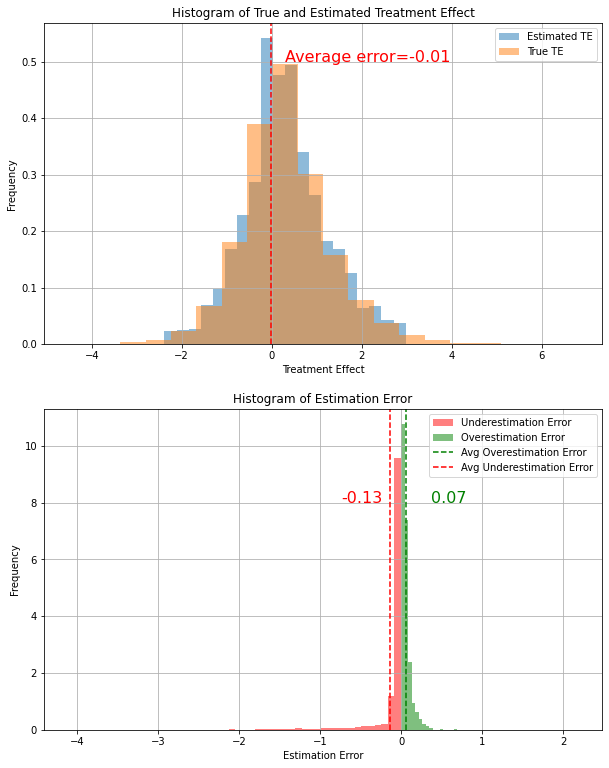

In [106]:
test_x_arr = generate_individual(**meta_dict, num_obs=1000, feat_dim=feat_dim)  # (num_cust, num_test_obs, feat_dim)
te_pred_arr, _ = estimate_via_vanila_causal_forest(vanilla_cf, test_x_arr.reshape(-1, feat_dim))
te_true_arr = te_func(test_x_arr).flatten()

err_arr = te_pred_arr - te_true_arr

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 13))

ax1.hist(te_pred_arr, bins=20, alpha=0.5, density=True, label='Estimated TE')
ax1.hist(te_true_arr, bins=20, alpha=0.5, density=True, label='True TE')
ax1.axvline(np.mean(err_arr), color='red', linestyle='--')
ax1.annotate(f'Average error={np.mean(err_arr):.2f}', (0.3 + np.mean(err_arr), 0.5), color='r', fontsize=16)
ax1.set_title('Histogram of True and Estimated Treatment Effect')
ax1.set_xlabel('Treatment Effect')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid()

under_est_arr = err_arr[err_arr < 0]
over_est_arr = err_arr[err_arr > 0]

ax2.hist(under_est_arr, bins=50, alpha=0.5, density=True, color='r', label='Underestimation Error')
ax2.hist(over_est_arr, bins=50, alpha=0.5, density=True, color='g', label='Overestimation Error')
ax2.axvline(over_est_arr.mean(), color='g', linestyle='--', label='Avg Overestimation Error')
ax2.annotate(f'{over_est_arr.mean():.2f}', (0.3 + over_est_arr.mean(), 8), color='g', fontsize=16)
ax2.axvline(under_est_arr.mean(), color='r', linestyle='--', label='Avg Underestimation Error')
ax2.annotate(f'{under_est_arr.mean():.2f}', (-0.6 + under_est_arr.mean(), 8), color='r', fontsize=16)
ax2.set_title('Histogram of Estimation Error')
ax2.set_xlabel('Estimation Error')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid()

plt.show()

In [103]:
""" 
Experiment wrapper
"""
def run_experiment(
    num_cust: int, num_obs: int, feat_dim: int, te_func: callable, budget: int, 
    num_test_obs: int, bootstrap_params: dict, meta_data: dict = None
) -> tuple:
    # generate raw data
    if meta_data is None:
        mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
    else:
        mu_arr, sigma_arr = meta_data['mu'], meta_data['sigma']
    meta_dict, data_dict = generate_training_set(num_cust, num_obs, feat_dim, te_func, meta_data={'mu': mu_arr, 'sigma': sigma_arr})
    test_x = generate_individual(**meta_dict, num_obs=num_test_obs, feat_dim=feat_dim)  # (num_cust, num_test_obs, feat_dim)

    # data preparation
    train_dict = prepare_training_data(data_dict)

    # train estimators
    vanilla_cf = train_vanilla_causal_forest(**train_dict)
    boot_cf_list = train_bootstrapped_causal_forest(**train_dict, **bootstrap_params)

    # estimate treatment effect for test data
    te_est_arr, _ = estimate_via_vanila_causal_forest(vanilla_cf, test_x.reshape(-1, test_x.shape[-1]))
    boot_te_est_df = estimate_via_bootstrapped_causal_forest(boot_cf_list, test_x.reshape(-1, test_x.shape[-1]))

    # making targeting decisions
    true_te_arr = te_func(test_x).flatten()
    best_targeting_arr = np.sort(np.argsort(-true_te_arr)[:budget])
    emp_targeting_val, emp_targeting_arr = empirical_targeting(te_est_arr, budget)
    boot_targeting_val, boot_targeting_arr = bootstrap_targeting(boot_te_est_df, budget)

    # evaluate targeting policies
    best_targeting_val = evaluate_targeting_policy(true_te_arr, best_targeting_arr)
    true_emp_targeting_val = evaluate_targeting_policy(true_te_arr, emp_targeting_arr)
    true_boot_targeting_val = evaluate_targeting_policy(true_te_arr, boot_targeting_arr)

    # compare results
    targeting_comp_df = pd.DataFrame({
        'Claivoyant': best_targeting_arr, 
        'Empirical': emp_targeting_arr,
        'Bootstrap': boot_targeting_arr
    })
    targeting_val_comp_df = pd.DataFrame({
        'Clairvoyant': {'in-sample': np.nan, 'out-of-sample': best_targeting_val}, 
        'Empirical': {'in-sample': emp_targeting_val, 'out-of-sample': true_emp_targeting_val},
        'Bootstrap': {'in-sample': boot_targeting_val, 'out-of-sample': true_boot_targeting_val}
    })

    return targeting_comp_df, targeting_val_comp_df

In [71]:
# experiment hyperparameters
num_repeat = 100 

# training parameters
num_cust = 20  # number of customers (or customer clusters)
num_obs = 200  # number of observations for each group of customers
feat_dim = 10  # number of features for each indivdiual
# te_func = lambda x_arr: np.maximum(x_arr[:, :, 0], 0)  # true treatment effect function
te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function

# testing parameters
num_test_obs = 1  # number of test observations for each group of customers

# decision making parameters
budget = 2  # number of customers to target

# bootstrap estimator parameters
boot_params_dict = {
    'num_bootstraps': 100, 'bootstrap_sample_size': 5 * num_cust * num_obs
}

# placeholders
targeting_comp_list = [None for _ in range(num_repeat)]
targeting_val_comp_list = [None for _ in range(num_repeat)]

# run experiments
mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
for i in tqdm(range(num_repeat)):
    targeting_comp_list[i], targeting_val_comp_list[i] = run_experiment(
        num_cust, num_obs, feat_dim, te_func, budget, num_test_obs, 
        bootstrap_params=boot_params_dict, meta_data={'mu': mu_arr, 'sigma': sigma_arr}
    )

100%|██████████| 100/100 [6:07:11<00:00, 220.32s/it] 


In [72]:
emp_is_val_bias_list = [
    df.loc['in-sample', 'Empirical'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list if df is not None
]
emp_oos_val_bias_list = [
    df.loc['out-of-sample', 'Empirical'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list if df is not None
]
emp_gen_err_list = [
    df.loc['in-sample', 'Empirical'] - df.loc['out-of-sample', 'Empirical']
    for df in targeting_val_comp_list if df is not None
]


boot_is_val_bias_list = [
    df.loc['in-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list if df is not None
]
boot_oos_val_bias_list = [
    df.loc['out-of-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list if df is not None
]
boot_gen_err_list = [
    df.loc['in-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Bootstrap']
    for df in targeting_val_comp_list if df is not None
]

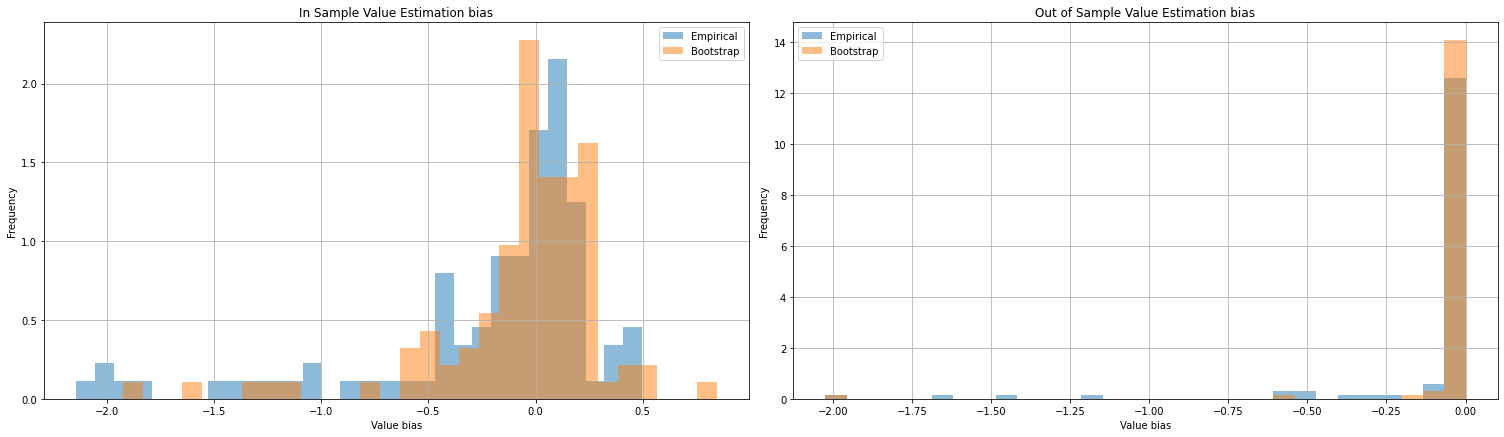

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 6.18))

ax1.hist(emp_is_val_bias_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax1.hist(boot_is_val_bias_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax1.set_xlabel('Value bias')
ax1.set_ylabel('Frequency')
ax1.set_title('In Sample Value Estimation bias')
ax1.legend()
ax1.grid()

ax2.hist(emp_oos_val_bias_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax2.hist(boot_oos_val_bias_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax2.set_xlabel('Value bias')
ax2.set_ylabel('Frequency')
ax2.set_title('Out of Sample Value Estimation bias')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

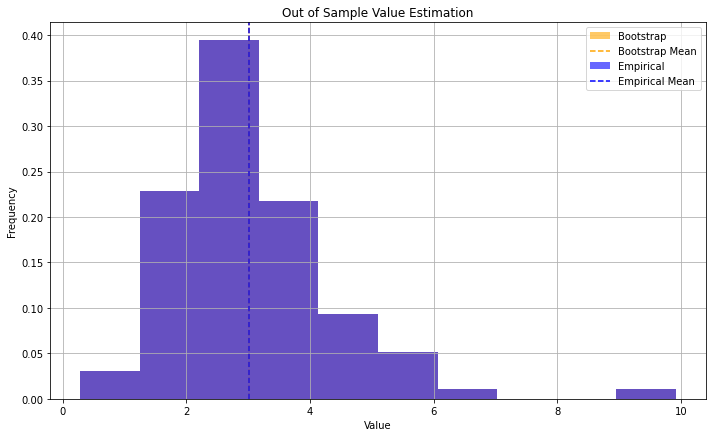

In [80]:
boot_val_list = [
    df.loc['out-of-sample', 'Bootstrap']
    for df in targeting_val_comp_list if df is not None
]
emp_val_list = [
    df.loc['out-of-sample', 'Empirical']
    for df in targeting_val_comp_list if df is not None
]

fig, ax = plt.subplots(figsize=(10, 6.18))

ax.hist(boot_val_list, alpha=0.6, color='orange', density=True, label='Bootstrap')
ax.axvline(np.mean(boot_val_list), color='orange', linestyle='--', label='Bootstrap Mean')
ax.hist(emp_val_list, alpha=0.6, color='blue', density=True, label='Empirical')
ax.axvline(np.mean(emp_val_list), color='blue', linestyle='--', label='Empirical Mean')

ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Out of Sample Value Estimation')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

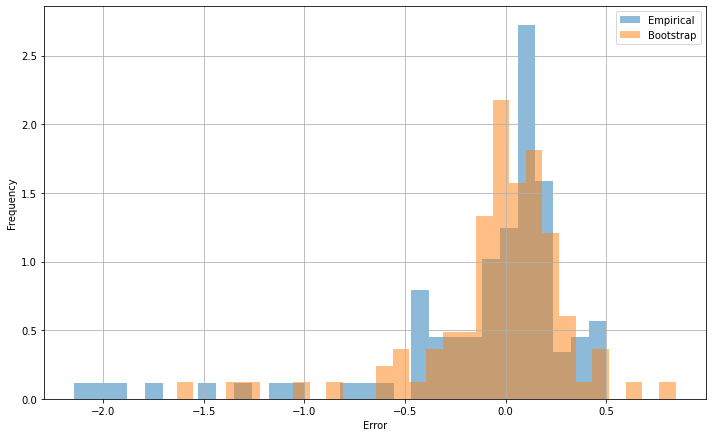

In [75]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.hist(emp_gen_err_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax.hist(boot_gen_err_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax.set_xlabel('Error')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [76]:
# experiment hyperparameters
num_repeat = 100 

# training parameters
num_cust = 10  # number of customers (or customer clusters)
num_obs = 150  # number of observations for each group of customers
feat_dim = 10  # number of features for each indivdiual
# te_func = lambda x_arr: np.maximum(x_arr[:, :, 0], 0)  # true treatment effect function
te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function

# testing parameters
num_test_obs = 1  # number of test observations for each group of customers

# decision making parameters
budget = 2  # number of customers to target

# bootstrap estimator parameters
boot_params_dict = {
    'num_bootstraps': 100, 'bootstrap_sample_size': num_cust * num_obs
}

# placeholders
targeting_comp_list = [None for _ in range(num_repeat)]
targeting_val_comp_list = [None for _ in range(num_repeat)]

# run experiments
mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
for i in tqdm(range(num_repeat)):
    targeting_comp_list[i], targeting_val_comp_list[i] = run_experiment(
        num_cust, num_obs, feat_dim, te_func, budget, num_test_obs, 
        bootstrap_params=boot_params_dict, meta_data={'mu': mu_arr, 'sigma': sigma_arr}
    )

100%|██████████| 100/100 [1:35:10<00:00, 57.10s/it]  


In [77]:
emp_is_val_bias_list = [
    df.loc['in-sample', 'Empirical'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list
]
emp_oos_val_bias_list = [
    df.loc['out-of-sample', 'Empirical'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list
]
emp_gen_err_list = [
    df.loc['in-sample', 'Empirical'] - df.loc['out-of-sample', 'Empirical']
    for df in targeting_val_comp_list
]


boot_is_val_bias_list = [
    df.loc['in-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list
]
boot_oos_val_bias_list = [
    df.loc['out-of-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Clairvoyant']
    for df in targeting_val_comp_list
]
boot_gen_err_list = [
    df.loc['in-sample', 'Bootstrap'] - df.loc['out-of-sample', 'Bootstrap']
    for df in targeting_val_comp_list
]

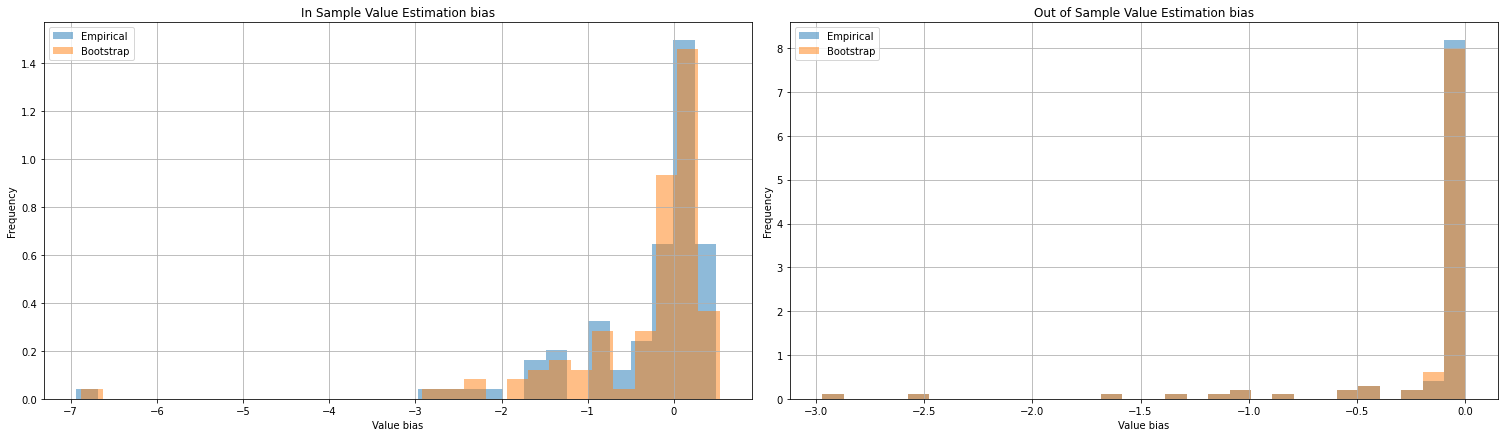

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 6.18))

ax1.hist(emp_is_val_bias_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax1.hist(boot_is_val_bias_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax1.set_xlabel('Value bias')
ax1.set_ylabel('Frequency')
ax1.set_title('In Sample Value Estimation bias')
ax1.legend()
ax1.grid()

ax2.hist(emp_oos_val_bias_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax2.hist(boot_oos_val_bias_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax2.set_xlabel('Value bias')
ax2.set_ylabel('Frequency')
ax2.set_title('Out of Sample Value Estimation bias')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

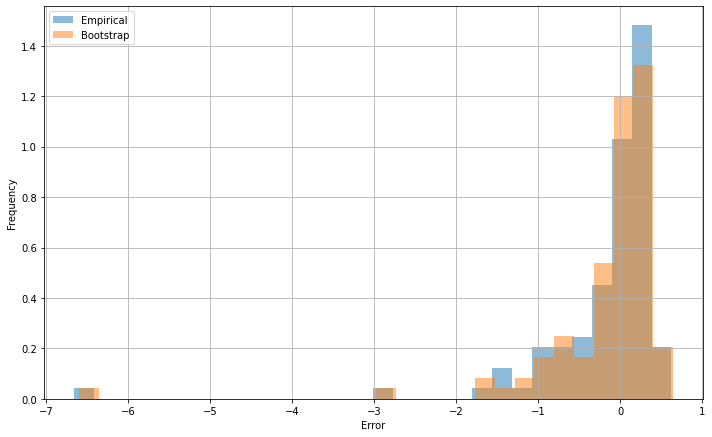

In [79]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.hist(emp_gen_err_list, bins=30, alpha=0.5, density=True, label='Empirical')
ax.hist(boot_gen_err_list, bins=30, alpha=0.5, density=True, label='Bootstrap')

ax.set_xlabel('Error')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [149]:
""" 
Experiment wrapper
"""
def run_emp_experiment(
    num_cust: int, num_obs: int, feat_dim: int, te_func: callable, budget: int, 
    num_test_obs: int, bootstrap_params: dict, meta_data: dict = None
) -> tuple:
    # generate raw data
    if meta_data is None:
        mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
    else:
        mu_arr, sigma_arr = meta_data['mu'], meta_data['sigma']
    meta_dict, data_dict = generate_training_set(num_cust, num_obs, feat_dim, te_func, meta_data={'mu': mu_arr, 'sigma': sigma_arr})
    test_x = generate_individual(**meta_dict, num_obs=num_test_obs, feat_dim=feat_dim)  # (num_cust, num_test_obs, feat_dim)

    # data preparation
    train_dict = prepare_training_data(data_dict)

    # train estimators
    vanilla_cf = train_vanilla_causal_forest(**train_dict)

    # estimate treatment effect for test data
    te_est_arr, _ = estimate_via_vanila_causal_forest(vanilla_cf, test_x.reshape(-1, test_x.shape[-1]))

    # making targeting decisions
    true_te_arr = te_func(test_x).flatten()
    best_targeting_arr = np.sort(np.argsort(-true_te_arr)[:budget])
    emp_targeting_val, emp_targeting_arr = empirical_targeting(te_est_arr, budget)

    # evaluate targeting policies
    best_targeting_val = evaluate_targeting_policy(true_te_arr, best_targeting_arr)
    true_emp_targeting_val = evaluate_targeting_policy(true_te_arr, emp_targeting_arr)

    # compare results
    est_comp_df = pd.DataFrame({
        'te_true': true_te_arr, 'te_pred': te_est_arr
    })
    targeting_comp_df = pd.DataFrame({
        'Clairvoyant': best_targeting_arr, 
        'Empirical': emp_targeting_arr,
    })
    targeting_val_comp_df = pd.DataFrame({
        'Clairvoyant': {'in-sample': np.nan, 'out-of-sample': best_targeting_val}, 
        'Empirical': {'in-sample': emp_targeting_val, 'out-of-sample': true_emp_targeting_val},
    })

    return est_comp_df, targeting_comp_df, targeting_val_comp_df

In [160]:
# experiment hyperparameters
num_repeat = 100 

# training parameters
num_cust = 50  # number of customers (or customer clusters)
num_obs = 1000  # number of observations for each group of customers
feat_dim = 10  # number of features for each indivdiual
# te_func = lambda x_arr: np.maximum(x_arr[:, :, 0], 0)  # true treatment effect function
# te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function
te_func = lambda x_arr: np.log(np.exp(10 * x_arr[:, :, 0] - 5 * x_arr[:, :, 1]**2) + np.exp(5 * x_arr[:, :, 2] - 2 * x_arr[:, :, 3])) + np.sin(x_arr[:, :, 4])

# testing parameters
num_test_obs = 1  # number of test observations for each group of customers

# decision making parameters
budget = 1  # number of customers to target

# bootstrap estimator parameters
boot_params_dict = {
    'num_bootstraps': 100, 'bootstrap_sample_size': 5 * num_cust * num_obs
}

# placeholders
est_comp_list = [None for _ in range(num_repeat)]
targeting_comp_list = [None for _ in range(num_repeat)]
targeting_val_comp_list = [None for _ in range(num_repeat)]

# run experiments
mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
for i in tqdm(range(num_repeat)):
    est_comp_list[i], targeting_comp_list[i], targeting_val_comp_list[i] = run_emp_experiment(
        num_cust, num_obs, feat_dim, te_func, budget, num_test_obs, 
        bootstrap_params=boot_params_dict, meta_data={'mu': mu_arr, 'sigma': sigma_arr}
    )

100%|██████████| 100/100 [05:44<00:00,  3.44s/it]


In [219]:
xi_list = [None for _ in range(num_repeat)]
delta_xi_list = [None for _ in range(num_repeat)]
err_list = [None for _ in range(num_repeat)]

for i in range(num_repeat):
    est_comp_df = est_comp_list[i]
    targeting_comp_df = targeting_comp_list[i]
    best_true_te_idx = targeting_comp_df.loc[0, 'Claivoyant']
    emp_targeting_idx = targeting_comp_df.loc[0, 'Empirical']

    err_list[i] = est_comp_df['te_pred'].sub(est_comp_df['te_true']).values

    xi_list[i] = est_comp_df.loc[best_true_te_idx, 'te_pred'] - est_comp_df.loc[best_true_te_idx, 'te_true']
    if best_true_te_idx == emp_targeting_idx:
        delta_xi_list[i] = 0
    else:
        emp_xi = est_comp_df.loc[emp_targeting_idx, 'te_pred'] - est_comp_df.loc[emp_targeting_idx, 'te_true']
        delta_xi_list[i] = emp_xi - xi_list[i]

err_arr = np.concatenate(err_list)
del err_list

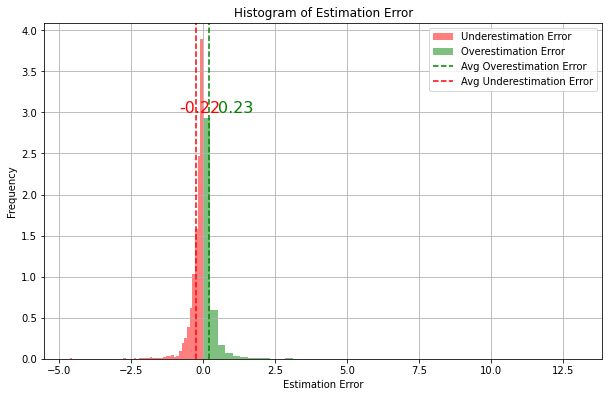

In [221]:
under_est_arr = err_arr[err_arr < 0]
over_est_arr = err_arr[err_arr > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(under_est_arr, bins=50, alpha=0.5, density=True, color='r', label='Underestimation Error')
ax.hist(over_est_arr, bins=50, alpha=0.5, density=True, color='g', label='Overestimation Error')
ax.axvline(over_est_arr.mean(), color='g', linestyle='--', label='Avg Overestimation Error')
ax.annotate(f'{over_est_arr.mean():.2f}', (0.3 + over_est_arr.mean(), 3), color='g', fontsize=16)
ax.axvline(under_est_arr.mean(), color='r', linestyle='--', label='Avg Underestimation Error')
ax.annotate(f'{under_est_arr.mean():.2f}', (-0.6 + under_est_arr.mean(), 3), color='r', fontsize=16)
ax.set_title('Histogram of Estimation Error')
ax.set_xlabel('Estimation Error')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid()

plt.show()

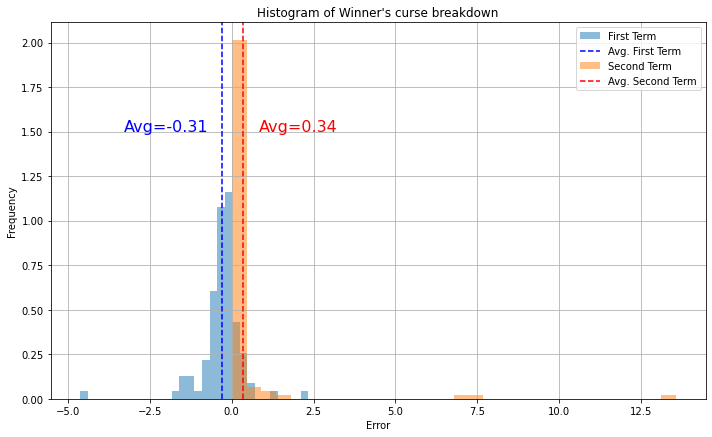

In [235]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.hist(xi_list, bins=30, alpha=0.5, density=True, label='First Term')
ax.axvline(np.mean(xi_list), color='blue', linestyle='--', label='Avg. First Term')
ax.annotate(f'Avg={np.mean(xi_list):.2f}', (-3 + np.mean(xi_list), 1.5), color='b', fontsize=16)

ax.hist(delta_xi_list, bins=30, alpha=0.5, density=True, label='Second Term')
ax.axvline(np.mean(delta_xi_list), color='r', linestyle='--', label='Avg. Second Term')
ax.annotate(f'Avg={np.mean(delta_xi_list):.2f}', (0.5 + np.mean(delta_xi_list), 1.5), color='r', fontsize=16)

ax.set_xlabel('Error')
ax.set_ylabel('Frequency')
ax.set_title("Histogram of Winner's curse breakdown")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

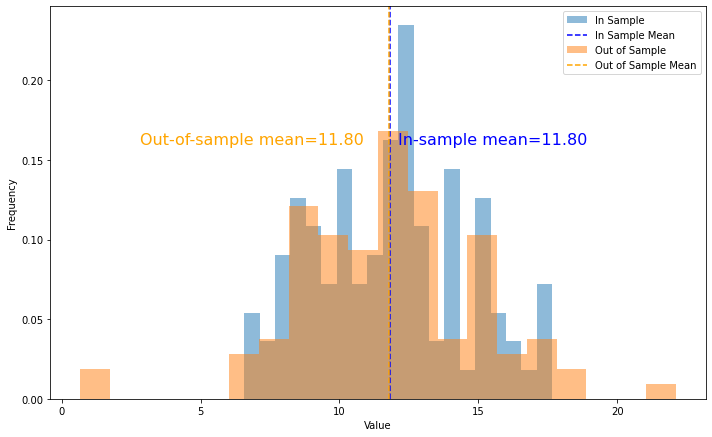

In [172]:
fig, ax = plt.subplots(figsize=(10, 6.18))

is_est_list = [df.loc['in-sample', 'Empirical'] for df in targeting_val_comp_list]
oos_est_list = [df.loc['out-of-sample', 'Empirical'] for df in targeting_val_comp_list]

ax.hist(is_est_list, bins=20, alpha=0.5, density=True, label='In Sample')
ax.axvline(np.mean(is_est_list), color='blue', linestyle='--', label='In Sample Mean')
ax.annotate(f'In-sample mean={np.mean(is_est_list):.2f}', ( np.mean(is_est_list) + 0.3, 0.16), color='blue', fontsize=16)
ax.hist(oos_est_list, bins=20, alpha=0.5, density=True, label='Out of Sample')
ax.axvline(np.mean(oos_est_list), color='orange', linestyle='--', label='Out of Sample Mean')
ax.annotate(f'Out-of-sample mean={np.mean(is_est_list):.2f}', (np.mean(is_est_list) - 9, 0.16), color='orange', fontsize=16)

ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

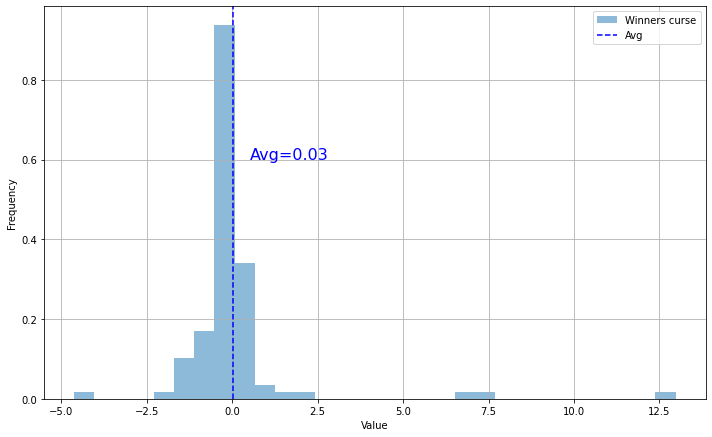

In [236]:
fig, ax = plt.subplots(figsize=(10, 6.18))

is_est_list = [df.loc['in-sample', 'Empirical'] for df in targeting_val_comp_list]
oos_est_list = [df.loc['out-of-sample', 'Empirical'] for df in targeting_val_comp_list]

winners_curse_list = [is_est - oos_est for is_est, oos_est in zip(is_est_list, oos_est_list)]

ax.hist(winners_curse_list, bins=30, alpha=0.5, density=True, label='Winners curse')
ax.axvline(np.mean(winners_curse_list), color='blue', linestyle='--', label='Avg')
ax.annotate(f'Avg={np.mean(winners_curse_list):.2f}', (np.mean(winners_curse_list) + 0.5, 0.6), color='blue', fontsize=16)

ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()